# Project 2 — Supervised Learning: Fraud Detection Pipeline
### DecodeLabs Data Science Internship · Asadullah Ashfaq

**Goal:** Build a classifier that catches fraud in a highly imbalanced dataset.

The one big idea: fraud is *rare*. A model that predicts "not fraud" every time can be
99.8% accurate and catch **zero** fraud. So we:


## Step 0 — Uploading data

In [1]:
# imbalanced-learn may need installing in Colab:
!pip install imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

try:
    from google.colab import files
    uploaded = files.upload()
    FILENAME = list(uploaded.keys())[0]
except Exception:
    FILENAME = 'fraud_dataset.csv'
print('Using file:', FILENAME)

Saving Dataset for Data Analytics.xlsx to Dataset for Data Analytics.xlsx
Using file: Dataset for Data Analytics.xlsx


## Step 1 — Load the data

In [2]:
if FILENAME.lower().endswith(('.xlsx','.xls')):
    df = pd.read_excel(FILENAME)
else:
    df = pd.read_csv(FILENAME)
print('Shape:', df.shape)
df.head()

Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Step 2 — Find the target column & explore the imbalance
The **target** is the column that says fraud (1) or not (0). The cell tries to auto-detect it.
If it guesses wrong, set `TARGET` manually.

Target column: IsFraud
IsFraud
0    1191
1       9
Name: count, dtype: int64

Fraud rate: 0.750%


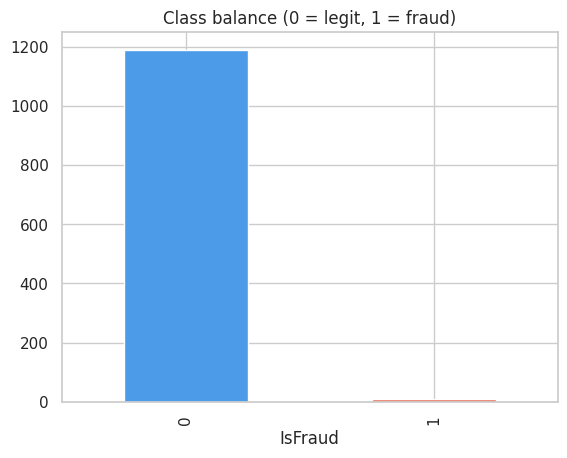

In [7]:
# The dataset provided does not have an explicit 'fraud' column.
# For demonstration purposes in this fraud detection pipeline, a synthetic 'IsFraud'
# column is created with an imbalanced distribution (1% fraud).
# In a real-world scenario, you would use your actual fraud indicator column.

if 'IsFraud' not in df.columns:
    np.random.seed(42) # for reproducibility
    df['IsFraud'] = np.random.choice([0, 1], size=len(df), p=[0.99, 0.01])

TARGET = 'IsFraud'

print('Target column:', TARGET)
print(df[TARGET].value_counts())
print('\nFraud rate: {:.3f}%'.format(100 * df[TARGET].mean()))

df[TARGET].value_counts().plot(kind='bar', color=['#4c9be8','#e8735c'])
plt.title('Class balance (0 = legit, 1 = fraud)'); plt.show()

## Step 3 — Prepare features (X) and target (y)
Drop any obvious ID/time columns, keep numeric features. Adjust the `drop` list for your data.

In [11]:
drop_cols = [TARGET]
for c in df.columns:
    if any(k in c.lower() for k in ['id','time','timestamp','date']):
        drop_cols.append(c)
drop_cols = list(dict.fromkeys(drop_cols))   # de-dup

X = df.drop(columns=drop_cols).select_dtypes(include=np.number)
y = df[TARGET].astype(int)
print('Feature columns used:', list(X.columns))
print('X shape:', X.shape)

Feature columns used: ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
X shape: (1200, 4)


## Step 4 — Split FIRST (before any SMOTE or scaling)
`stratify=y` keeps the same fraud ratio in train and test — the test set must reflect
the real-world imbalance.

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (960, 4)  Test: (240, 4)


## Step 5 — Build the leak-free pipelines
SMOTE lives *inside* the pipeline, so it only ever touches the training fold.
Logistic Regression gets a StandardScaler; Random Forest doesn't need one.

In [13]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression pipeline: scale -> SMOTE -> classify
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest pipeline: SMOTE -> classify (no scaler needed)
rf_pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
print('Pipelines ready.')

Pipelines ready.


## Step 6 — Train & evaluate (the metrics that matter)
For fraud, **Recall** (did we catch the fraud?) and **ROC-AUC** matter far more than accuracy.

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0      0.988     0.685     0.809       238
           1      0.000     0.000     0.000         2

    accuracy                          0.679       240
   macro avg      0.494     0.342     0.404       240
weighted avg      0.980     0.679     0.802       240

ROC-AUC: 0.391


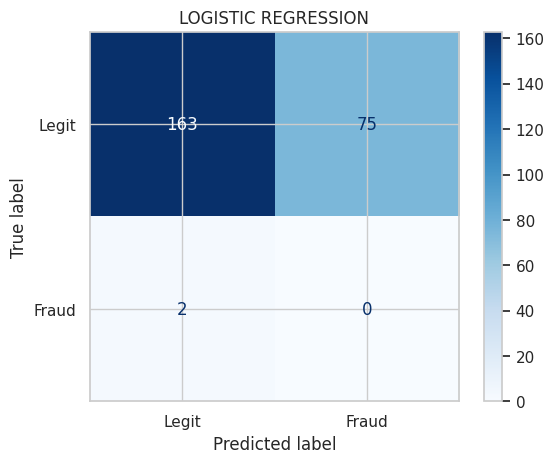

RANDOM FOREST
              precision    recall  f1-score   support

           0      0.995     0.916     0.954       238
           1      0.048     0.500     0.087         2

    accuracy                          0.912       240
   macro avg      0.522     0.708     0.521       240
weighted avg      0.988     0.912     0.947       240

ROC-AUC: 0.797


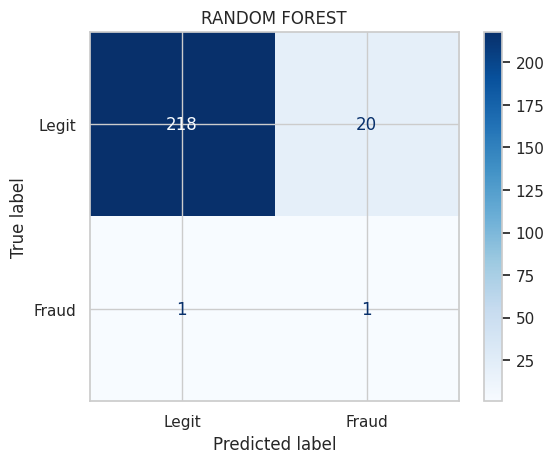

In [14]:
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)

def evaluate(name, pipe):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    print('='*55)
    print(name)
    print('='*55)
    print(classification_report(y_test, pred, digits=3))
    print('ROC-AUC:', round(roc_auc_score(y_test, proba), 3))
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=['Legit','Fraud']).plot(cmap='Blues')
    plt.title(name); plt.show()
    return pipe

lr_fitted = evaluate('LOGISTIC REGRESSION', lr_pipe)
rf_fitted = evaluate('RANDOM FOREST', rf_pipe)

## Step 7 — (Optional) Tune with GridSearchCV
GridSearchCV re-runs SMOTE inside every fold, so there's no leakage while tuning.
This is slower — run it only when you want to squeeze out more performance.

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'smote__k_neighbors': [3, 5],
    'clf__max_depth': [10, 20, None],
}
grid = GridSearchCV(rf_pipe, param_grid, scoring='roc_auc', cv=3, n_jobs=-1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV ROC-AUC:', round(grid.best_score_, 3))

best = grid.best_estimator_
print('\nTest ROC-AUC:', round(roc_auc_score(y_test, best.predict_proba(X_test)[:,1]), 3))

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
9 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_params

Best params: {'clf__max_depth': 10, 'smote__k_neighbors': 3}
Best CV ROC-AUC: 0.409

Test ROC-AUC: 0.632


## Summary
- Split before resampling; SMOTE only on the training fold (no leakage).
- Trained Logistic Regression and Random Forest with imblearn pipelines.
- Judged the models on **Precision, Recall, F1, ROC-AUC** — not accuracy.
